# GAN Training & Finetuning
All GAN-relevant functions, architecture, and helpers for face generation and finetuning on personal faces.

In [3]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import tqdm as tq

In [4]:
def get_device():
    if torch.backends.mps.is_available():
        print("Using Apple Silicon GPU (MPS)")
        return "mps"
    elif torch.cuda.is_available():
        print("Using CUDA GPU")
        return "cuda"
    else:
        print("Using CPU")
        return "cpu"


## 2. Define GAN Architectures (Generator & Discriminator)
Implementation of Generator and Discriminator classes (StyleGAN-inspired).

In [ ]:
import torch
import torch.nn as nn

# ===============================
# Generator
# ===============================
class Generator(nn.Module):
    def __init__(self, latent_dim=128, img_channels=3, feature_maps=64):
        super().__init__()

        # Latent vector → 4x4 Feature Map
        self.fc = nn.Linear(latent_dim, feature_maps * 8 * 4 * 4)

        self.conv_blocks = nn.Sequential(
            # (fm*8, 4, 4)
            nn.BatchNorm2d(feature_maps * 8),

            # 4x4 → 8x8
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            # 8x8 → 16x16
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            # 16x16 → 32x32
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            # 32x32 → 64x64
            nn.ConvTranspose2d(feature_maps, feature_maps // 2, 4, 2, 1),
            nn.BatchNorm2d(feature_maps // 2),
            nn.ReLU(True),

            # 64x64 → 128x128
            nn.ConvTranspose2d(feature_maps // 2, feature_maps // 4, 4, 2, 1),
            nn.BatchNorm2d(feature_maps // 4),
            nn.ReLU(True),

            # 128x128 → 256x256
            nn.ConvTranspose2d(feature_maps // 4, img_channels, 4, 2, 1),

            # Output in [-1, 1]
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), -1, 4, 4)
        img = self.conv_blocks(x)
        return img


# ===============================
# Discriminator
# ===============================
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # 256x256 → 128x128
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 128x128 → 64x64
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64 → 32x32
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 → 16x16
            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 → 1x1 (GAN score)
            nn.Conv2d(feature_maps * 8, 1, 16, 1, 0)
        )

    def forward(self, img):
        x = self.conv_blocks(img)
        return x.view(-1)


In [6]:

# class FaceDataset(Dataset):
#     def __init__(self, root_dir, transform=None, include_me=True, include_others=True):
#         self.files = []
#         if include_me:
#             self.files += glob.glob(os.path.join(root_dir, "me", "*.jpg"))
#         if include_others:
#             self.files += glob.glob(os.path.join(root_dir, "others_aligned", "*.jpg"))
#         self.transform = transform if transform else transforms.Compose([
#             transforms.Resize((256,256)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.5]*3, [0.5]*3)
#         ])
#     def __len__(self):
#         return len(self.files)
#     def __getitem__(self, idx):
#         img = Image.open(self.files[idx]).convert("RGB")
#         return self.transform(img)

import os, glob, random
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class FaceDataset(Dataset):
    def __init__(
        self,
        root_dir,
        transform=None,
        include_me=True,
        include_others=True,
        me_ratio=0.25
    ):
        self.me_files = []
        self.other_files = []

        if include_me:
            self.me_files = glob.glob(os.path.join(root_dir, "me", "*.jpg"))

        if include_others:
            self.other_files = glob.glob(
                os.path.join(root_dir, "others_aligned", "*.jpg")
            )

        if include_me and include_others:
            assert len(self.me_files) > 0, "No 'me' images found"
            assert len(self.other_files) > 0, "No 'others' images found"

        self.include_me = include_me
        self.include_others = include_others
        self.me_ratio = me_ratio

        self.transform = transform if transform else transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        # Virtuelle Länge = dominante Klasse (Celeb)
        self.length = (
            len(self.other_files)
            if include_others
            else len(self.me_files)
        )

    def __len__(self):
        return self.length

    def _load(self, path):
        img = Image.open(path).convert("RGB")
        return self.transform(img)

    def __getitem__(self, idx):
        # -------- MIX MODE --------
        if self.include_me and self.include_others:
            if random.random() < self.me_ratio:
                path = random.choice(self.me_files)      # 25 %
            else:
                path = random.choice(self.other_files)   # 75 %
            return self._load(path)

        # -------- ONLY ME --------
        if self.include_me:
            path = self.me_files[idx % len(self.me_files)]
            return self._load(path)

        # -------- ONLY OTHERS --------
        path = self.other_files[idx % len(self.other_files)]
        return self._load(path)



In [ ]:
def train_gan(generator, discriminator, dataloader, epochs=20, device="cpu"):
    generator.train()
    discriminator.train()

    g_opt = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        for real_imgs in tq.tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # --------------------
            # Train Discriminator (2x)
            # --------------------
            for _ in range(2):
                z = torch.randn(batch_size, 128, device=device)
                fake_imgs = generator(z)

                d_real = discriminator(real_imgs)
                d_fake = discriminator(fake_imgs.detach())

                real_labels = torch.empty_like(d_real).uniform_(0.8, 1.0)
                fake_labels = torch.empty_like(d_fake).uniform_(0.0, 0.2)

                loss_real = criterion(d_real, real_labels)
                loss_fake = criterion(d_fake, fake_labels)
                d_loss = (loss_real + loss_fake) / 2

                d_opt.zero_grad()
                d_loss.backward()
                d_opt.step()

            # --------------------
            # Train Generator
            # --------------------
            d_fake = discriminator(fake_imgs)
            gen_labels = torch.empty_like(d_fake).uniform_(0.8, 1.0)

            g_loss = criterion(d_fake, gen_labels)

            g_opt.zero_grad()
            g_loss.backward()
            g_opt.step()

        print(f"Epoch {epoch+1}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

    return generator, discriminator


In [ ]:
def finetune_gan_on_me(generator, discriminator, ml_dir, device="cpu", epochs=10):
    dataset_me = FaceDataset(ml_dir, include_me=True, include_others=False)
    loader_me = DataLoader(dataset_me, batch_size=32, shuffle=True)
    train_gan(generator, discriminator, loader_me, epochs=epochs, device=device)


In [ ]:
# Sequence: select device, initialize models, load datasets, train GAN, finetune, save model
ML_DIR = "../ml_photos"

# 1. Select device
device = get_device()

# 2. Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)


In [ ]:
# 3. Load datasets
# GAN training on all faces
dataset = FaceDataset(ML_DIR, include_me=False, include_others=True)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 4. Train GAN
train_gan(generator, discriminator, loader, epochs=50, device=device)

In [ ]:
dataset = FaceDataset(ML_DIR, include_me=True, include_others=True)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 4. Train GAN
train_gan(generator, discriminator, loader, epochs=30, device=device)

In [ ]:
# 5. Finetune GAN on 'me'
finetune_gan_on_me(generator, discriminator, ML_DIR, device=device, epochs=30)

WGAN-GP (Wassesrstein GAN with Gradient Penalty):

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=128, img_channels=3, feature_maps=64):
        super().__init__()

        self.fc = nn.Linear(latent_dim, feature_maps * 8 * 4 * 4)

        self.net = nn.Sequential(
            # 4x4
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32
            nn.ConvTranspose2d(feature_maps, feature_maps // 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64
            nn.ConvTranspose2d(feature_maps // 2, feature_maps // 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 128x128 → 256x256
            nn.ConvTranspose2d(feature_maps // 4, img_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), -1, 4, 4)
        return self.net(x)

class Critic(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 8, 1, 16, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)

def gradient_penalty(critic, real, fake, device):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=device)
    interp = alpha * real + (1 - alpha) * fake
    interp.requires_grad_(True)

    score = critic(interp)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad = grad.view(grad.size(0), -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp


In [8]:
def train_wgan_gp(generator, critic, dataloader, epochs, device, learning_rate_generator=1e-4, learning_rate_critic=4e-4, λ_gp=10, n_critic=5):
    generator.train()
    critic.train()

    g_opt = torch.optim.Adam(generator.parameters(), lr=learning_rate_generator, betas=(0.0, 0.9))
    c_opt = torch.optim.Adam(critic.parameters(), lr=learning_rate_critic, betas=(0.0, 0.9))

    for epoch in range(epochs):
        for real_imgs in dataloader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ------------------
            # Train Critic
            # ------------------
            for _ in range(n_critic):
                z = torch.randn(batch_size, 128, device=device)
                fake_imgs = generator(z).detach()

                real_score = critic(real_imgs)
                fake_score = critic(fake_imgs)

                gp = gradient_penalty(critic, real_imgs, fake_imgs, device)
                c_loss = fake_score.mean() - real_score.mean() + λ_gp * gp

                c_opt.zero_grad()
                c_loss.backward()
                c_opt.step()

            # ------------------
            # Train Generator
            # ------------------
            z = torch.randn(batch_size, 128, device=device)
            fake_imgs = generator(z)
            g_loss = -critic(fake_imgs).mean()

            g_opt.zero_grad()
            g_loss.backward()
            g_opt.step()

        print(f"Epoch {epoch+1}/{epochs} | C: {c_loss.item():.3f} | G: {g_loss.item():.3f}")


In [9]:
ML_DIR = "../ml_photos"

# 1. Select device
device = get_device()

# 2. Initialize models
generator = Generator().to(device)
critic = Critic().to(device)

# 3. Load weights if available
critic_path = "../models/critic_me.pth"
generator_path = "../models/generator_me.pth"

if os.path.exists(critic_path):
    critic.load_state_dict(torch.load(critic_path, map_location=device))
    print(f"Loaded critic weights from {critic_path}")
else:
    print(f"Critic weights not found at {critic_path}")

if os.path.exists(generator_path):
    generator.load_state_dict(torch.load(generator_path, map_location=device))
    print(f"Loaded generator weights from {generator_path}")
else:
    print(f"Generator weights not found at {generator_path}")


Using Apple Silicon GPU (MPS)
Loaded critic weights from ../models/critic_me.pth
Loaded generator weights from ../models/generator_me.pth


In [ ]:
# 4. Train GAN

dataset = FaceDataset(ML_DIR, include_me=False, include_others=True)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
train_wgan_gp(
    generator,
    critic,
    loader,
    epochs=19,   #maybe 50-100, more better??
    device=device,
    learning_rate_generator=1e-4,
    learning_rate_critic=4e-4,
    λ_gp=10,
    n_critic=3
    )

# ca. 33 daweil


Epoch 1/19 | C: -9.922 | G: -414.114
Epoch 2/19 | C: -6.965 | G: 604.344
Epoch 3/19 | C: -77.299 | G: 383.332
Epoch 4/19 | C: -4.886 | G: -450.791
Epoch 5/19 | C: -26.657 | G: -238.864
Epoch 6/19 | C: 49.125 | G: 235.318
Epoch 7/19 | C: -76.188 | G: -883.414
Epoch 8/19 | C: -26.580 | G: -1129.239
Epoch 9/19 | C: -12.490 | G: 944.884
Epoch 10/19 | C: -25.040 | G: 560.420
Epoch 11/19 | C: -1.818 | G: -569.526
Epoch 12/19 | C: -47.492 | G: -1426.185


KeyboardInterrupt: 

In [75]:
dataset = FaceDataset(ML_DIR, include_me=False, include_others=True)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
train_wgan_gp(
    generator,
    critic,
    loader,
    epochs=10,
    device=device,
    learning_rate_generator=1e-4,
    learning_rate_critic=2e-4,
    λ_gp=5,
    n_critic=2
    )

Epoch 1/10 | C: -60.579 | G: -1040.786
Epoch 2/10 | C: 115.647 | G: -2498.430


KeyboardInterrupt: 

In [106]:
dataset = FaceDataset(ML_DIR, include_me=True, include_others=True, me_ratio=0.25)

loader = DataLoader(dataset, batch_size=8, shuffle=True)
train_wgan_gp(
    generator,
    critic,
    loader,
    epochs=20,
    device=device,
    learning_rate_generator=5e-5,
    learning_rate_critic=2e-4,
    λ_gp=10,
    n_critic=3
    )


Epoch 1/20 | C: -106.917 | G: -1202.616
Epoch 2/20 | C: -64.690 | G: 3261.929
Epoch 3/20 | C: -116.509 | G: 132.260
Epoch 4/20 | C: 18.150 | G: -282.767
Epoch 5/20 | C: -496.021 | G: 959.447
Epoch 6/20 | C: -98.825 | G: -2180.045
Epoch 7/20 | C: -35.618 | G: -889.108
Epoch 8/20 | C: -774.864 | G: -3938.652


KeyboardInterrupt: 

In [ ]:
dataset = FaceDataset(ML_DIR, include_me=True, include_others=False)
loader = DataLoader(dataset, batch_size=4, shuffle=True)
train_wgan_gp(
    generator,
    critic,
    loader,
    epochs=5,
    device=device,
    learning_rate_generator=1e-5,
    learning_rate_critic=1e-4,
    λ_gp=10,
    n_critic=2
)


Try out and save

In [10]:
# 6. Save generator and critic model

def save_generator_model(generator, critic=None, model_dir="../models", model_name="generator_me.pth", hf_dir_name="generator_me_hf", critic_name="critic_me.pth"):
    import os
    import json
    os.makedirs(model_dir, exist_ok=True)

    # PyTorch-save (.pth) for generator
    pth_path = os.path.join(model_dir, model_name)
    torch.save(generator.state_dict(), pth_path)
    print(f"Finetuned generator saved as PyTorch state_dict: {pth_path}")

    # Save critic if provided
    if critic is not None:
        critic_path = os.path.join(model_dir, critic_name)
        torch.save(critic.state_dict(), critic_path)
        print(f"Critic saved as PyTorch state_dict: {critic_path}")

    # Hugging Face / FastAPI-kompatibel
    hf_dir = os.path.join(model_dir, hf_dir_name)
    os.makedirs(hf_dir, exist_ok=True)

    # save as full model + config for Web Deployment
    hf_model_path = os.path.join(hf_dir, "pytorch_model.bin")
    torch.save(generator.state_dict(), hf_model_path)

    # Minimal config.json for HF / Inference
    config = {
        "model_type": "generator",
        "image_size": 256,
        "latent_dim": 128,
        "description": "Finetuned GAN generator for faces"
    }
    with open(os.path.join(hf_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    print(f"Finetuned generator saved in HF-style format: {hf_dir}")

# Beispielaufruf: Speichere Generator und Critic
save_generator_model(generator, critic=critic, model_dir="../models", model_name="generator_me2.pth", hf_dir_name="generator_me2_hf", critic_name="critic_me2.pth")

Finetuned generator saved as PyTorch state_dict: ../models/generator_me2.pth
Critic saved as PyTorch state_dict: ../models/critic_me2.pth
Finetuned generator saved in HF-style format: ../models/generator_me2_hf


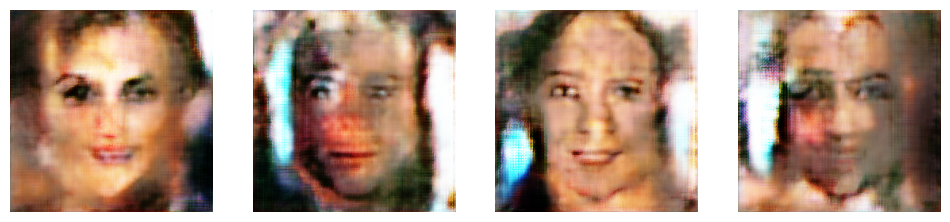

In [45]:
# Test a saved generator model and visualize generated samples
import matplotlib.pyplot as plt

def test_saved_generator(model_path="../models/generator_me.pth", latent_dim=128, num_samples=4, device=None):
    device = get_device()
    gen = Generator(latent_dim=latent_dim).to(device)
    gen.load_state_dict(torch.load(model_path, map_location=device))
    gen.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, device=device)
        samples = gen(z).cpu() * 0.5 + 0.5  # denormalize to [0,1]
    fig, axs = plt.subplots(1, num_samples, figsize=(num_samples*3, 3))
    if num_samples == 1:
        axs = [axs]
    for i, img in enumerate(samples):
        axs[i].imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
        axs[i].axis('off')
    plt.show()

def test_generator_in_memory(generator, latent_dim=128, num_samples=4, device=None):
    device = device or get_device()
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, device=device)
        samples = generator(z).cpu() * 0.5 + 0.5  # denormalize to [0,1]
    fig, axs = plt.subplots(1, num_samples, figsize=(num_samples*3, 3))
    if num_samples == 1:
        axs = [axs]
    for i, img in enumerate(samples):
        axs[i].imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
        axs[i].axis('off')
    plt.show()

# Beispiel: Testen des aktuellen Generators im Speicher (ohne zu speichern)
test_generator_in_memory(generator, latent_dim=128, num_samples=4, device=device)

# Beispiel: Testen eines gespeicherten Generators
#test_saved_generator(model_path="../models/generator_me.pth", latent_dim=128, num_samples=4, device=device)